# 🏴‍☠️ AN2DL Challenge 1: Pirate Pain Dataset

## Notebook 03: Model Development, Hyperparameter Tuning and Final Training

This is the third and final notebook in the series for the AN2DL Challenge 1 on the Pirate Pain Dataset. In this notebook, we focus on developing and tuning our deep learning model to achieve optimal performance.

This notebook covers the following key steps:
1. **Model Definition**: We define the architecture of our deep learning model, which combines Temporal Convolutional Networks (TCN) and Bidirectional Long Short-Term Memory (BiLSTM) layers with attention mechanisms.
2. **Hyperparameter Tuning**: We perform an extensive hyperparameter search (approximately 288 configuration combinations $\times$ 5-fold CV = 1440 training runs) to identify the best class-2 multiplier, batch size, dropout rate, and model width. The search is conducted using stratified group K-Fold cross-validation to ensure robust evaluation.
3. **Final Training and Evaluation**: Using the best hyperparameters identified from the tuning phase, we retrain the model on the entire training dataset and evaluate its performance on the test set. We also implement test-time augmentation (TTA) to enhance prediction robustness.
4. **Plotting and Submission**: We generate summary plots to visualize the hyperparameter tuning results and prepare the final submission file for the challenge.

In [6]:
import json
from typing import TypedDict

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from sklearn.model_selection import StratifiedGroupKFold
from torch.utils.data import DataLoader, WeightedRandomSampler

import internal.utils.telegram_utils as tg
from internal.data_types import PainDataset
from internal.nn.models.pain_tcn_bilstm_attn import PainTCNBiLSTMAttn
from internal.nn.training.pain_tcn_bilstm_attn_trainer import PainTCNBiLSTMAttnTrainer
from internal.persistence_manager import PersistenceManager

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

### Inference Helper Functions

Due to the high level of competition in the Kaggle challenge, we conducted an extensive hyperparameter search to identify the optimal configuration for our `PainTCNBiLSTMAttn` model. However, hyperparameter tuning alone does not guarantee optimal performance on the test set. To enhance our model's robustness and accuracy further, we searched for techniques to apply during inference time.

We implemented two inference helper functions: one for standard inference without test-time augmentation (TTA) and another for inference with TTA. These functions allow us to obtain logits from the model, which can be used to make predictions.

#### Inference without TTA (logits only)

In classification tasks, the last layer of the model typically outputs raw and unnormalized scores; for example, for 3 classes: `logits = [2.1, -1.3, 0.7]`. These are called **logits**. They are not probabilities and can be any real number. To convert logits to probabilities, we apply the softmax function, which transforms these scores into a probability distribution over the classes.

However, sometimes we don't want probabilities directly (e.g., for temperature scaling). So we extract the logits directly from the model without applying softmax. This allows us to manipulate the logits (like scaling them) before converting them to probabilities later if needed.

Finally, the logits is used by the inference TTA function to perform test-time augmentation (see below).


#### Inference with TTA

We have seen that the inference made by a single forward pass of the model may be sensitive to small perturbations in the input data. So we have searched for ways to make the inference more robust. One effective technique found is **Test-Time Augmentation (TTA)**. It runs the model on augmented version of the same input, then average the predictions. It is a simple yet effective way to improve model robustness and accuracy.

Is a single forward pass sensitive to small perturbations in the input data? Let's examine the sequence under different tiny perturbations to see what the model consistently predicts.

Reference: Wang, Guotai, et al. "Automatic brain tumor segmentation using convolutional neural networks with test-time augmentation." International MICCAI Brainlesion Workshop. Cham: Springer International Publishing, 2018. (https://link.springer.com/chapter/10.1007/978-3-030-11726-9_6).

In [20]:
@torch.no_grad()
def infer_logits(
        _model: PainTCNBiLSTMAttn,
        _x_num: np.ndarray,
        _x_surv: list[np.ndarray],
        _x_sta: np.ndarray,
        _x_summ: np.ndarray,
        batch_size: int = 32
) -> np.ndarray:
    """
    A helper function for running the model forward in inference mode to obtain logits.

    :param _model: The trained PainTCNBiLSTMAttn model.
    :param _x_num: Numeric dynamic features (N, T, D_num).
    :param _x_surv: List of survival dynamic features, each of shape (N, T, D_surv_i).
    :param _x_sta: Static features (N, D_sta).
    :param _x_summ: Summary dynamic features (N, D_summ).
    :param batch_size: Batch size for inference.
    :return: Logits array of shape (N, 3).
    """
    # set model to eval mode (disable dropout, etc.)
    _model.eval()
    # create DataLoader for batching
    ds = PainDataset(_x_num, _x_surv, _x_sta, _x_summ)
    dl = DataLoader(ds, batch_size=batch_size, shuffle=False, num_workers=4, pin_memory=True)
    predictions = []
    # iterate over batches
    for b in dl:
        x_num  = b['x_num'].to(device)
        x_sta  = b['x_sta'].to(device)
        x_surv = [s.to(device) for s in b['x_surv']]
        x_summ = b['x_summ'].to(device)
        # forward pass (no softmax)
        logits = _model(x_num, x_surv, x_sta, x_summ)  # (B,3)
        predictions.append(logits.detach().cpu().numpy())
    return np.concatenate(predictions, axis=0)  # (N,3)

@torch.no_grad()
def infer_logits_tta(
        _model: PainTCNBiLSTMAttn,
        _x_num: np.ndarray,
        _x_surv: list[np.ndarray],
        _x_sta: np.ndarray,
        _x_summ: np.ndarray,
        _n_aug: int = 5,
        _noise_std: float = 0.01,
        _roll: int = 2,
        _batch: int = 32
) -> np.ndarray:
    """
    A helper function for running the model forward in inference mode with Test-Time Augmentation (TTA) to obtain logits.

    More specifically, it applies small Gaussian noise and tiny circular time shifts to the numeric dynamic features.
    :param _model: The trained PainTCNBiLSTMAttn model.
    :param _x_num: Numeric dynamic features (N, T, D_num).
    :param _x_surv: List of survival dynamic features, each of shape (N, T, D_surv_i).
    :param _x_sta: Static features (N, D_sta).
    :param _x_summ: Summary dynamic features (N, D_summ).
    :param _n_aug: Number of augmentations to perform.
    :param _noise_std: Standard deviation of Gaussian noise to add.
    :param _roll: Maximum circular time shift (in time steps).
    :param _batch: Batch size for inference.
    :return: Logits array of shape (N, 3).
    """
    # set model to eval mode (disable dropout, etc.)
    _model.eval()
    # accumulate logits from multiple augmentations
    outs = []
    # for each augmentation
    for _k in range(_n_aug):
        # copy original numeric features to avoid modifying them
        xn = _x_num.copy()
        if _k > 0:
            # add Gaussian noise, makes the model more robust to small variations
            xn += np.random.normal(0, _noise_std, size=xn.shape).astype(xn.dtype)
            # shift the sequence slightly in time (circularly), simulating time misalignment
            shift = np.random.randint(-_roll, _roll + 1)
            if shift != 0:
                xn = np.roll(xn, shift=shift, axis=1)  # roll along the time
        # infer logits for this augmented input
        outs.append(infer_logits(_model, xn, _x_surv, _x_sta, _x_summ, batch_size=_batch))
    # average logits across augmentations
    # why not softmax probabilities? Averaging probabilities gives inconsistent gradients and biases;
    # Averaging logits means combine raw model scores and then normalize once at the end (more stable).
    return np.mean(outs, axis=0)  # (N,3)


In [3]:
class HyperparamScore(TypedDict):
    """ Record of hyperparameter combination and its CV score. """
    multiplier: float
    """ Class-2 multiplier. """
    batch_size: int
    """ Batch size. """
    dropout: float
    """ Dropout rate. """
    width: int
    """ Model width (TCN channels and LSTM hidden size). """
    mean_f1: float
    """ Mean F1 score across CV folds. """
    std_f1: float
    """ Standard deviation of F1 score across CV folds. """

In [5]:
# load data
data = PersistenceManager.load_arrays_v2()

# set the seed for reproducibility
seed = 2021
np.random.seed(seed)
torch.manual_seed(seed)

# prepare stratified group K-Fold
skf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=seed)
pid_all     = np.concatenate([data.pid_train,        data.pid_val],         axis=0)
y_all       = np.concatenate([data.y_train,          data.y_val],           axis=0)
X_num_all   = np.concatenate([data.X_dyn_num_train,  data.X_dyn_num_val],   axis=0)
X_sta_all   = np.concatenate([data.X_sta_train,      data.X_sta_val],       axis=0)
X_surv_all  = [np.concatenate([data.X_surv_train[i], data.X_surv_val[i]],   axis=0) for i in range(4)]
X_summ_all  = np.concatenate([data.X_dyn_summ_train, data.X_dyn_summ_val],  axis=0)

all_scores: list[HyperparamScore] = []
multipliers = [0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1]
batch_sizes = [16, 24, 32]
dropouts    = [0.3, 0.4, 0.5]
widths      = [32, 64, 96, 128]

# to store per-multiplier CV stats
mult_stats: dict[float, dict[str, float]] = {}

# trainer instance
trainer = PainTCNBiLSTMAttnTrainer(
    classes=[0, 1, 2],
    epochs=1000,
    patience=28,
    warmup_epochs=20,
    p_drop_summ=0.3,
    summary_window=data.feat_eng.window,
    device=device
)

# notify me about phase A start
tg.send_message("🚀 Phase A: Searching best class-2 multiplier via CV...", raise_on_failure=False)

for mul in multipliers:
    for bs in batch_sizes:
        for dropout in dropouts:
            for width in widths:
                print(f"Multiplier: {mul}, Batch size: {bs}, Dropout: {dropout}, Width: {width}")

                f1_scores = []

                log_filename = f"log/log_mul{mul}_bs{bs}_drop{dropout}_width{width}.log"

                print(f"=== Running config: mul={mul}, bs={bs}, drop={dropout}, width={width} ===")

                for k, (tr_idx, va_idx) in enumerate(skf.split(X=np.zeros(len(y_all)), y=y_all, groups=pid_all)):
                    print(f"  Fold {k}...")

                    # --- prepare datasets ---
                    Xtr_num, Xva_num    = X_num_all[tr_idx], X_num_all[va_idx]
                    Xtr_sta, Xva_sta    = X_sta_all[tr_idx], X_sta_all[va_idx]
                    Xtr_surv = [s[tr_idx] for s in X_surv_all]
                    Xva_surv = [s[va_idx] for s in X_surv_all]
                    Xtr_summ, Xva_summ  = X_summ_all[tr_idx], X_summ_all[va_idx]
                    ytr, yva            = y_all[tr_idx],      y_all[va_idx]
                    pid_tr, pid_va      = pid_all[tr_idx],    pid_all[va_idx]

                    # --- sanity check: no leakage ---
                    assert set(pid_tr).isdisjoint(set(pid_va)), "Patient leaked between train and val!"

                    # --- create datasets ---
                    train_ds = PainDataset(Xtr_num, Xtr_surv, Xtr_sta, Xtr_summ, ytr)
                    val_ds   = PainDataset(Xva_num, Xva_surv, Xva_sta, Xva_summ, yva)

                    # --- create weighted sampler for class balancing ---
                    class_counts = np.bincount(ytr, minlength=3).astype(np.float32)
                    inv = 1.0 / np.clip(class_counts, 1, None)
                    inv = inv / inv.mean()
                    alpha = 0.5
                    w_class = np.power(inv, alpha)
                    cap = 5.0
                    w_class = np.minimum(w_class, cap * w_class.mean())
                    sample_w = w_class[ytr]
                    sampler = WeightedRandomSampler(
                        weights=torch.tensor(sample_w, dtype=torch.double),
                        num_samples=len(ytr),
                        replacement=True
                    )

                    # --- create data loaders that use the sampler ---
                    train_loader = DataLoader(train_ds, batch_size=bs, shuffle=False, sampler=sampler, num_workers=4, pin_memory=True)
                    val_loader   = DataLoader(val_ds,   batch_size=bs, shuffle=False, num_workers=4, pin_memory=True)

                    # -- calculate priors from training fold ---
                    counts_tr = np.bincount(ytr, minlength=3).astype(np.float32)
                    priors_tr = counts_tr / counts_tr.sum()

                    # --- Train on this fold ---
                    model, f1, best_b, t_fold, best_tau = trainer.train_one_fold(
                        model=PainTCNBiLSTMAttn(
                            d_num=90,
                            d_emb=4,
                            d_sta=7,
                            d_summ=data.X_dyn_summ_train.shape[1],
                            tcn_channels=width,
                            lstm_hidden=width,
                            num_classes=3,
                            dropout=dropout
                        ).to(device),
                        k=k,
                        train_loader=train_loader,
                        val_loader=val_loader,
                        y_train=ytr,
                        y_val=yva,
                        priors=priors_tr,
                        class_multipliers={2: mul}
                    )

                    # record fold score
                    f1_scores.append(f1)

                # after all folds, compute mean/std for this multiplier
                mean_m = float(np.mean(f1_scores))
                std_m  = float(np.std(f1_scores))
                all_scores.append({
                    "multiplier": mul,
                    "batch_size": bs,
                    "dropout": dropout,
                    "width": width,
                    "mean_f1": mean_m,
                    "std_f1": std_m,
                })

                # notify me about this multiplier's CV result
                print(f"[Phase A] mul={mul}, bs={bs}, dropout={dropout}, width={width}: mean={mean_m:.4f} std={std_m:.4f}")
                tg.send_message(
                    f"📊 [Phase A] mul={mul}, bs={bs}, dropout={dropout}, width={width} → mean F1={mean_m:.4f}, std={std_m:.4f}",
                    raise_on_failure=False
                )

# after all multipliers, print summary
print("=== [Phase A] Class-2 Multiplier Search Complete ===")

# Step 1: best mean
best_mean = max(s['mean_f1'] for s in all_scores)
# Step 2: tolerance window
TOL = 0.005
candidates = [
    s for s in all_scores
    if s['mean_f1'] >= best_mean - TOL
]
# Step 3: pick the one with smallest std among candidates
best_candidate = min(candidates, key=lambda s: s['std_f1'])

print("Best candidate multiplier search result:")
print(f"  multiplier: {best_candidate['multiplier']}")
print(f"  batch_size: {best_candidate['batch_size']}")
print(f"  dropout:    {best_candidate['dropout']}")
print(f"  width:      {best_candidate['width']}")

tg.send_message(
    f"🏆 [Phase A] Best candidate: mul={best_candidate['multiplier']}, "f"bs={best_candidate['batch_size']}, "
    f"dropout={best_candidate['dropout']}, width={best_candidate['width']} → "
    f"mean F1={best_candidate['mean_f1']:.4f}, std={best_candidate['std_f1']:.4f}",
    raise_on_failure=False
)

Arrays v2 loaded successfully from: /home/andre/university/AN2DL-Challenge-1/notebooks/processed/arrays_v2.joblib
Multiplier: 0.3, Batch size: 16, Dropout: 0.3, Width: 32
=== Running config: mul=0.3, bs=16, drop=0.3, width=32 ===
  Fold 0...
[F0 001] t_loss=0.3517 | F1(macro)=0.5140 | rec=[0.99 0.   0.8 ] | lr=1.00e-03 | patience=1/28
[F0 002] t_loss=0.2675 | F1(macro)=0.4808 | rec=[0.961 0.    0.9  ] | lr=1.00e-03 | patience=1/28
[F0 003] t_loss=0.2266 | F1(macro)=0.5387 | rec=[0.922 0.15  0.8  ] | lr=1.00e-03 | patience=2/28
[F0 004] t_loss=0.2055 | F1(macro)=0.6652 | rec=[0.892 0.4   1.   ] | lr=1.00e-03 | patience=1/28
[F0 005] t_loss=0.1769 | F1(macro)=0.6673 | rec=[0.98 0.3  0.8 ] | lr=1.00e-03 | patience=1/28
[F0 006] t_loss=0.0963 | F1(macro)=0.7802 | rec=[0.902 0.7   1.   ] | lr=1.00e-03 | patience=1/28
[F0 007] t_loss=0.0776 | F1(macro)=0.7558 | rec=[0.951 0.5   1.   ] | lr=1.00e-03 | patience=1/28
[F0 008] t_loss=0.0636 | F1(macro)=0.7260 | rec=[0.873 0.6   1.   ] | lr=1.00e

True

Best candidates saved to artifacts/hyperparameter_research.json


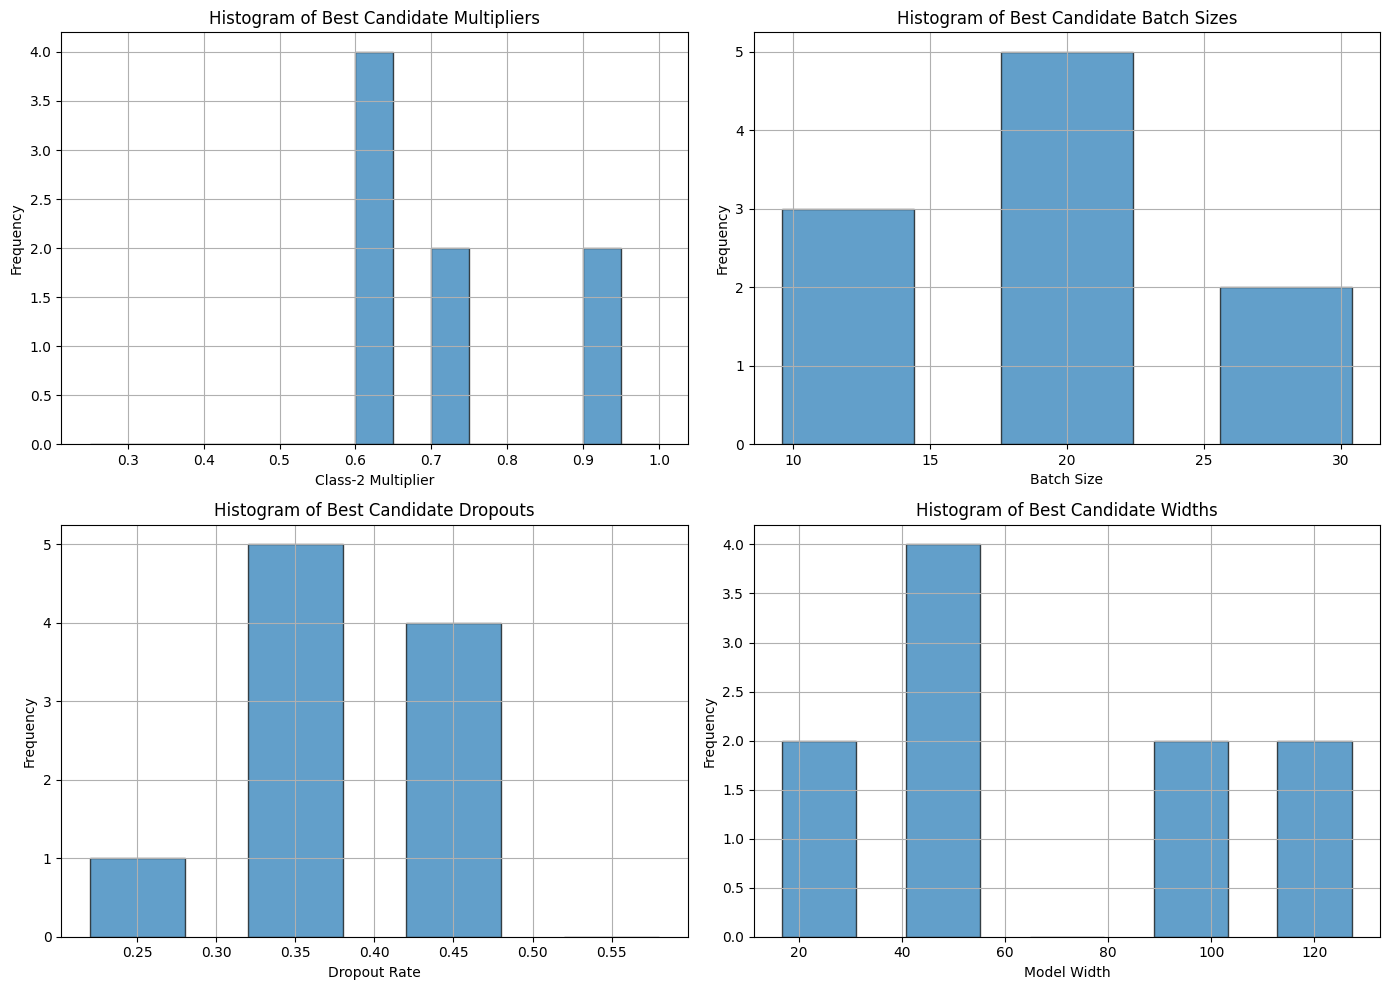

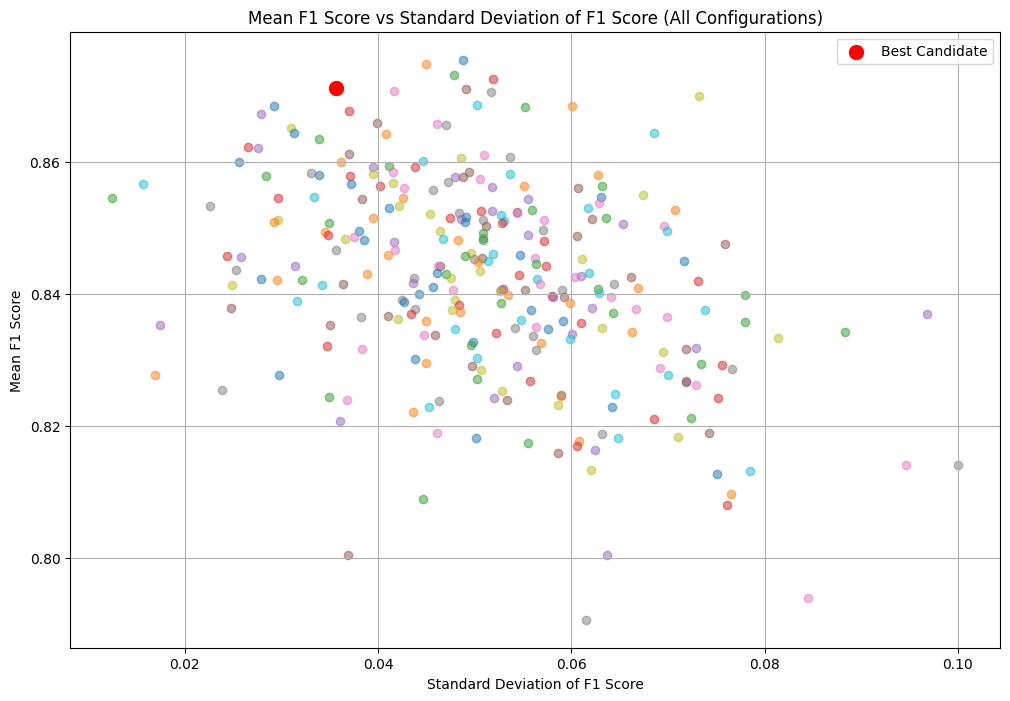

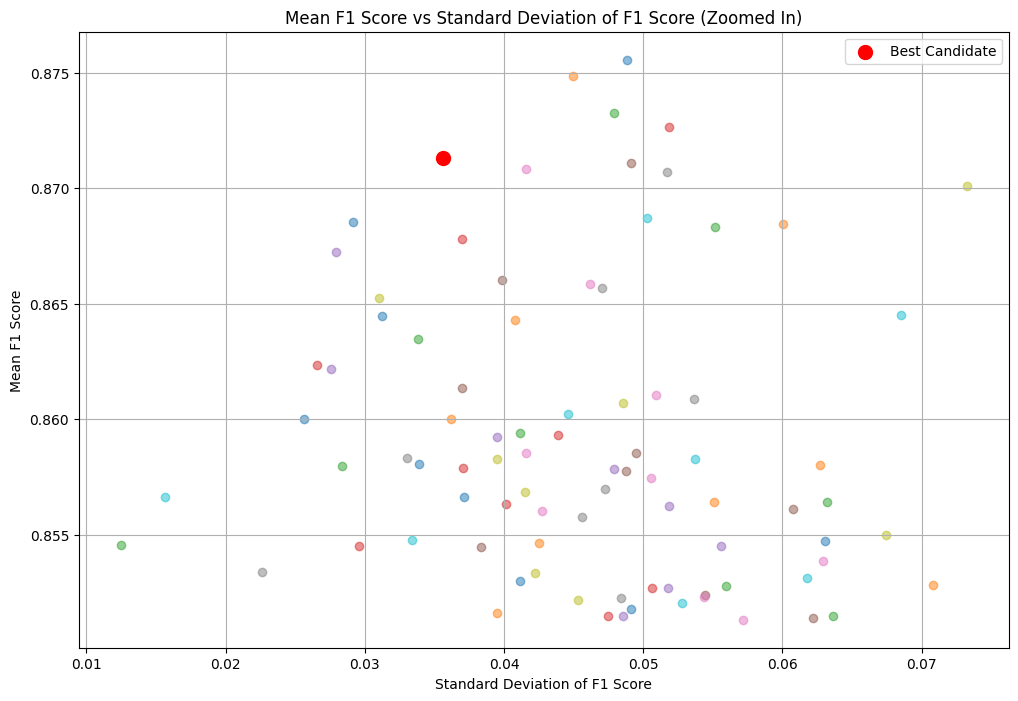

In [19]:
best_candidates_sorted = sorted(all_scores, key=lambda s: s['mean_f1'], reverse=True)
try:
    with open('artifacts/hyperparameter_research.json', 'w') as f:
        json.dump(best_candidates_sorted, f, indent=4)
    print("Best candidates saved to artifacts/hyperparameter_research.json")
except Exception as e:
    print(f"Error saving best candidates: {e}")

# Summary plots
fig, axs = plt.subplots(2, 2, figsize=(14, 10))
# Histogram of Best Candidate Multipliers (top sx)
best_mul_values = [s['multiplier'] for s in best_candidates_sorted[:10]]
axs[0, 0].hist(best_mul_values, bins=np.arange(0.25, 1.05, 0.05), alpha=0.7, edgecolor='black')
axs[0, 0].set_title('Histogram of Best Candidate Multipliers')
axs[0, 0].set_xlabel('Class-2 Multiplier')
axs[0, 0].set_ylabel('Frequency')
axs[0, 0].grid(True)
# Histogram of Best Candidate Batch Sizes (top dx)
best_bs_values = [s['batch_size'] for s in best_candidates_sorted[:10]]
axs[0, 1].hist(best_bs_values, bins=[12, 20, 28, 36], alpha=0.7, edgecolor='black', align='left', rwidth=0.6)
axs[0, 1].set_title('Histogram of Best Candidate Batch Sizes')
axs[0, 1].set_xlabel('Batch Size')
axs[0, 1].set_ylabel('Frequency')
axs[0, 1].grid(True)
# Histogram of Best Candidate Dropouts (bottom sx)
best_dropout_values = [s['dropout'] for s in best_candidates_sorted[:10]]
axs[1, 0].hist(best_dropout_values, bins=[0.25, 0.35, 0.45, 0.55, 0.65], alpha=0.7, edgecolor='black', align='left', rwidth=0.6)
axs[1, 0].set_title('Histogram of Best Candidate Dropouts')
axs[1, 0].set_xlabel('Dropout Rate')
axs[1, 0].set_ylabel('Frequency')
axs[1, 0].grid(True)
# Histogram of Best Candidate Widths (bottom dx)
best_width_values = [s['width'] for s in best_candidates_sorted[:10]]
axs[1, 1].hist(best_width_values, bins=[24, 48, 72, 96, 120, 144], alpha=0.7, edgecolor='black', align='left', rwidth=0.6)
axs[1, 1].set_title('Histogram of Best Candidate Widths')
axs[1, 1].set_xlabel('Model Width')
axs[1, 1].set_ylabel('Frequency')
axs[1, 1].grid(True)
plt.tight_layout()
plt.savefig('figures/best_candidate_hyperparameters_comparison.pdf')

# Plot std vs mean for all configurations
plt.figure(figsize=(12, 8))
for s in all_scores:
    plt.scatter(s['std_f1'], s['mean_f1'], alpha=0.5)
plt.scatter(best_candidate['std_f1'], best_candidate['mean_f1'], color='red', s=100, label='Best Candidate')
plt.title('Mean F1 Score vs Standard Deviation of F1 Score (All Configurations)')
plt.xlabel('Standard Deviation of F1 Score')
plt.ylabel('Mean F1 Score')
plt.legend()
plt.grid(True)
plt.savefig('figures/mean_f1_vs_std_f1_all_configurations.pdf')

# Zoomed-in focus around best candidate
plt.figure(figsize=(12, 8))
for s in all_scores:
    if s['mean_f1'] >= best_candidate['mean_f1'] - 0.02:
        plt.scatter(s['std_f1'], s['mean_f1'], alpha=0.5)
plt.scatter(best_candidate['std_f1'], best_candidate['mean_f1'], color='red', s=100, label='Best Candidate')
plt.title('Mean F1 Score vs Standard Deviation of F1 Score (Zoomed In)')
plt.xlabel('Standard Deviation of F1 Score')
plt.ylabel('Mean F1 Score')
plt.legend()
plt.grid(True)
plt.savefig('figures/mean_f1_vs_std_f1_zoomed_in.pdf')

In [6]:
# --- Phase B: Final training with the best multiplier and test ensembling ---

# to store test logits from each fold
test_fold_logits = []
# to store final fold scores
fold_scores_final = []
# to store temperatures within final folds
temperatures = []
# to store taus within final folds
taus = []

# notify me about phase B start
tg.send_message(
    f"🚀 Phase B: Final training with best candidate and test ensembling...",
    raise_on_failure=False
)

# K-Fold CV loop with best multiplier and test logits
for k, (tr_idx, va_idx) in enumerate(skf.split(X=np.zeros(len(y_all)),
                                               y=y_all,
                                               groups=pid_all)):
    print(f"=== [Phase B] Fold {k} (grouped by patient) ===")

    # --- prepare datasets ---
    Xtr_num, Xva_num    = X_num_all[tr_idx], X_num_all[va_idx]
    Xtr_sta, Xva_sta    = X_sta_all[tr_idx], X_sta_all[va_idx]
    Xtr_surv            = [s[tr_idx] for s in X_surv_all]
    Xva_surv            = [s[va_idx] for s in X_surv_all]
    Xtr_summ, Xva_summ  = X_summ_all[tr_idx], X_summ_all[va_idx]
    ytr, yva            = y_all[tr_idx],      y_all[va_idx]
    pid_tr, pid_va      = pid_all[tr_idx],    pid_all[va_idx]

    # --- sanity check: no leakage ---
    assert set(pid_tr).isdisjoint(set(pid_va)), "Patient leaked between train and val!"

    # --- create datasets ---
    train_ds = PainDataset(Xtr_num, Xtr_surv, Xtr_sta, Xtr_summ, ytr)
    val_ds   = PainDataset(Xva_num, Xva_surv, Xva_sta, Xva_summ, yva)

    # --- create weighted sampler for class balancing ---
    class_counts = np.bincount(ytr, minlength=3).astype(np.float32)
    inv = 1.0 / np.clip(class_counts, 1, None)
    inv = inv / inv.mean()
    alpha = 0.5
    w_class = np.power(inv, alpha)
    cap = 5.0
    w_class = np.minimum(w_class, cap * w_class.mean())
    sample_w = w_class[ytr]
    sampler = WeightedRandomSampler(
        weights=torch.tensor(sample_w, dtype=torch.double),
        num_samples=len(ytr),
        replacement=True
    )

    # --- create data loaders that use the sampler ---
    train_loader = DataLoader(train_ds, batch_size=best_candidate['batch_size'], shuffle=False, sampler=sampler, num_workers=4, pin_memory=True)
    val_loader   = DataLoader(val_ds,   batch_size=best_candidate['batch_size'], shuffle=False, num_workers=4, pin_memory=True)

    # -- calculate priors from training fold ---
    counts_tr = np.bincount(ytr, minlength=3).astype(np.float32)
    priors_tr = counts_tr / counts_tr.sum()

    # --- Train on this fold ---
    model, f1, best_b, t_fold, best_tau = trainer.train_one_fold(
        model=PainTCNBiLSTMAttn(
            d_num=90,
            d_emb=4,
            d_sta=7,
            d_summ=data.X_dyn_summ_train.shape[1],
            tcn_channels=best_candidate['width'],
            lstm_hidden=best_candidate['width'],
            num_classes=3,
            dropout=best_candidate['dropout']
        ).to(device),
        k=k,
        train_loader=train_loader,
        val_loader=val_loader,
        y_train=ytr,
        y_val=yva,
        priors=priors_tr,
        class_multipliers={2: best_candidate['multiplier']}
    )

    # --- record fold score ---
    fold_scores_final.append(f1)
    temperatures.append(t_fold)
    taus.append(best_tau)

    # --- infer test logits with TTA ---
    logits_te = infer_logits_tta(
        model,
        data.X_dyn_num_test,
        data.X_surv_test,
        data.X_sta_test,
        data.X_dyn_summ_test,
        _n_aug=5, _noise_std=0.01, _roll=2,
        _batch=best_candidate['batch_size']
    ).astype(np.float32)

    # --- temperature scaling (per-fold scalar) ---
    logits_te = logits_te / float(t_fold)

    # -- prior correction with the best tau and bias ---
    log_p = np.log(np.clip(priors_tr, 1e-8, 1.0)).astype(np.float32)
    logits_te = logits_te + best_tau * log_p[None, :]
    logits_te = logits_te + best_b[None, :]

    # --- store for ensembling ---
    test_fold_logits.append(logits_te)

# --- ensemble and submission ---
logits_stack = np.stack(test_fold_logits, axis=0)   # (5, N_test, 3)
logits_avg   = logits_stack.mean(axis=0)            # (N_test, 3)
pred_idx     = logits_avg.argmax(axis=1)

idx_to_label = {0:'no_pain', 1:'low_pain', 2:'high_pain'}
pred_labels  = [idx_to_label[int(i)] for i in pred_idx]

ids_test = [f'{i:03}' for i in range(len(pred_labels))]
sub = pd.DataFrame({'sample_index': ids_test, 'label': pred_labels})

_filename = f'PainTCNBiLSTMAttn_final_mul{best_candidate["multiplier"]}_bs{best_candidate["batch_size"]}_dropout{best_candidate["dropout"]}_width{best_candidate["width"]}'
sub.to_csv(f'submissions/{_filename}.csv', index=False)
print("Saved:", f'submissions/{_filename}.csv')
tg.send_file(
    f'submissions/{_filename}.csv',
    caption=f"✅ Submission from Phase B: Final model with mul={best_candidate['multiplier']}, "
            f"bs={best_candidate['batch_size']}, dropout={best_candidate['dropout']}, "
            f"width={best_candidate['width']}.",
    raise_on_failure=False
)

print(f"[Phase B] Final CV results: mean F1={np.mean(fold_scores_final):.4f} std={np.std(fold_scores_final):.4f}")
tg.send_message(
    f"✅ [Phase B] Done. CV mean={np.mean(fold_scores_final):.4f} std={np.std(fold_scores_final):.4f}",
    False
)


=== [Phase B] Fold 0 (grouped by patient) ===
[F0 001] t_loss=0.3965 | F1(macro)=0.4245 | rec=[0.99 0.   0.4 ] | lr=1.00e-03 | patience=1/28
[F0 002] t_loss=0.3911 | F1(macro)=0.5447 | rec=[0.98 0.75 0.  ] | lr=1.00e-03 | patience=1/28
[F0 003] t_loss=0.3219 | F1(macro)=0.5852 | rec=[0.922 0.55  0.3  ] | lr=1.00e-03 | patience=1/28
[F0 004] t_loss=0.2846 | F1(macro)=0.6263 | rec=[0.971 0.7   0.2  ] | lr=1.00e-03 | patience=1/28
[F0 005] t_loss=0.2517 | F1(macro)=0.5433 | rec=[0.961 0.1   0.9  ] | lr=1.00e-03 | patience=1/28
[F0 006] t_loss=0.2442 | F1(macro)=0.7477 | rec=[0.902 0.8   0.7  ] | lr=1.00e-03 | patience=2/28
[F0 007] t_loss=0.2011 | F1(macro)=0.7444 | rec=[0.951 0.7   0.6  ] | lr=1.00e-03 | patience=1/28
[F0 008] t_loss=0.1765 | F1(macro)=0.7637 | rec=[0.902 0.75  0.8  ] | lr=1.00e-03 | patience=2/28
[F0 009] t_loss=0.1378 | F1(macro)=0.7988 | rec=[0.971 0.75  0.7  ] | lr=1.00e-03 | patience=1/28
[F0 010] t_loss=0.1566 | F1(macro)=0.7188 | rec=[0.873 0.65  0.9  ] | lr=1.00e

True